In [1]:
import cv2
import numpy as np
import os

In [2]:
img_path = "sar_1.jpg"
# img_path = "sar_1_gray.jpg"
image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

(1024, 2048) (675, 1200)


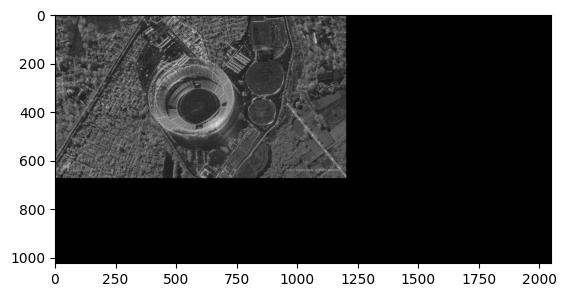

In [3]:
import numpy as np
import cv2 as cv2
from matplotlib import pyplot as plt


def pad_to_power_of_2(image):
    h, w = image.shape
    h_new = 1
    while h_new < h:
        h_new *= 2
    w_new = 1
    while w_new < w:
        w_new *= 2

    padded = np.zeros((h_new, w_new), dtype=image.dtype)
    padded[:h, :w] = image
    return padded, (h, w)


image_padded, original_size = pad_to_power_of_2(image_gray)

print(image_padded.shape, original_size)

plt.imshow(image_padded, cmap="gray")

In [4]:
original_text = "orig.txt"

# for row in image_gray:
#     for pixel in row:
#         f.write(f"{pixel}\n")
with open(original_text, "w") as f:
    for pixel in image_gray[: original_size[0], : original_size[1]].flatten():
        f.write(f"{pixel}\n")

In [5]:
def haar_wavelet_2d(image):
    h, w = image.shape
    h2, w2 = h // 2, w // 2

    temp = np.zeros_like(image, dtype=np.float64)
    temp[:, :w2] = (image[:, ::2] + image[:, 1::2]) / np.sqrt(2)
    temp[:, w2:] = (image[:, ::2] - image[:, 1::2]) / np.sqrt(2)

    result = np.zeros_like(image, dtype=np.float64)
    result[:h2, :] = (temp[::2, :] + temp[1::2, :]) / np.sqrt(2)
    result[h2:, :] = (temp[::2, :] - temp[1::2, :]) / np.sqrt(2)

    return result

coeffs = haar_wavelet_2d(image_padded.astype(np.float64))
coeffs

array([[170. , 179. , 133.5, ...,   0. ,   0. ,   0. ],
       [130. , 114.5, 115. , ...,   0. ,   0. ,   0. ],
       [142.5, 104. , 112.5, ...,   0. ,   0. ,   0. ],
       ...,
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ]],
      shape=(1024, 2048))

In [6]:
def threshold_detail_coefficients(coeffs, threshold):
    h, w = coeffs.shape
    h2, w2 = h // 2, w // 2

    thresholded = coeffs.copy()

    thresholded[:h2, w2:] = np.where(
        np.abs(thresholded[:h2, w2:]) < threshold, 0, thresholded[:h2, w2:]
    )
    thresholded[h2:, :w2] = np.where(
        np.abs(thresholded[h2:, :w2:]) < threshold, 0, thresholded[h2:, :w2:]
    )
    thresholded[h2:, w2:] = np.where(
        np.abs(thresholded[h2:, w2:]) < threshold, 0, thresholded[h2:, w2:]
    )

    return thresholded

threshold = 10
coeffs_thresholded = threshold_detail_coefficients(coeffs, threshold)
coeffs_thresholded

array([[170. , 179. , 133.5, ...,   0. ,   0. ,   0. ],
       [130. , 114.5, 115. , ...,   0. ,   0. ,   0. ],
       [142.5, 104. , 112.5, ...,   0. ,   0. ,   0. ],
       ...,
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ]],
      shape=(1024, 2048))

In [7]:
coeffs_rounded = np.round(coeffs_thresholded).astype(np.int32)
coeffs_rounded

array([[170, 179, 133, ...,   0,   0,   0],
       [130, 114, 115, ...,   0,   0,   0],
       [142, 104, 112, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(1024, 2048), dtype=int32)

In [8]:
def rle_encode(data):
    encoded = []
    zero_count = 0

    for value in data:
        if value == 0:
            zero_count += 1
        else:
            encoded.append((zero_count, int(value)))
            zero_count = 0

    if zero_count > 0:
        encoded.append((zero_count, 0))

    return encoded

rle_data = rle_encode(coeffs_rounded.flatten())
rle_data

[(0, 170),
 (0, 179),
 (0, 133),
 (0, 106),
 (0, 87),
 (0, 110),
 (0, 108),
 (0, 104),
 (0, 116),
 (0, 113),
 (0, 119),
 (0, 124),
 (0, 127),
 (0, 130),
 (0, 144),
 (0, 130),
 (0, 124),
 (0, 130),
 (0, 116),
 (0, 118),
 (0, 104),
 (0, 110),
 (0, 113),
 (0, 118),
 (0, 110),
 (0, 106),
 (0, 108),
 (0, 107),
 (0, 127),
 (0, 170),
 (0, 174),
 (0, 197),
 (0, 226),
 (0, 195),
 (0, 181),
 (0, 144),
 (0, 210),
 (0, 223),
 (0, 210),
 (0, 162),
 (0, 181),
 (0, 176),
 (0, 119),
 (0, 126),
 (0, 165),
 (0, 135),
 (0, 126),
 (0, 120),
 (0, 111),
 (0, 113),
 (0, 154),
 (0, 203),
 (0, 198),
 (0, 186),
 (0, 172),
 (0, 187),
 (0, 195),
 (0, 213),
 (0, 176),
 (0, 143),
 (0, 98),
 (0, 116),
 (0, 82),
 (0, 132),
 (0, 97),
 (0, 95),
 (0, 94),
 (0, 70),
 (0, 85),
 (0, 112),
 (0, 115),
 (0, 114),
 (0, 99),
 (0, 98),
 (0, 112),
 (0, 100),
 (0, 95),
 (0, 90),
 (0, 91),
 (0, 111),
 (0, 128),
 (0, 130),
 (0, 100),
 (0, 126),
 (0, 140),
 (0, 101),
 (0, 92),
 (0, 93),
 (0, 91),
 (0, 94),
 (0, 83),
 (0, 102),
 (0, 1

In [9]:
compressed_file = "compressed.rle"
with open(compressed_file, "w") as f:
    for zero_count, value in rle_data:
        f.write(f"{zero_count} {value}\n")

In [10]:
original_size = os.path.getsize(original_text)
compressed_size = os.path.getsize(compressed_file)
original_size / compressed_size

1.3230047918027645

In [11]:
ratios = []

from glob import glob

images = ["sar_1.jpg", "sar_1_gray.jpg"]
images = glob("data/tmp/*_noised.png")[:10]

for img_path in images:
    image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    image_padded, original_size = pad_to_power_of_2(image_gray)

    original_text = "orig.txt"
    with open(original_text, "w") as f:
        for pixel in image_gray[: original_size[0], : original_size[1]].flatten():
            f.write(f"{pixel}\n")

    coeffs = haar_wavelet_2d(image_padded.astype(np.float64))
    coeffs_thresholded = threshold_detail_coefficients(coeffs, threshold)
    coeffs_rounded = np.round(coeffs_thresholded).astype(np.int32)
    rle_data = rle_encode(coeffs_rounded.flatten())

    compressed_file = "compressed.rle"
    with open(compressed_file, "w") as f:
        for zero_count, value in rle_data:
            f.write(f"{zero_count} {value}\n")

    ratio = os.path.getsize(original_text) / os.path.getsize(compressed_file)

    ratios.append(ratio)

ratios

[1.2821286591396606,
 1.277750894658869,
 1.245297301301431,
 1.3006604541024671,
 1.875463134334038,
 1.251459871019584,
 1.5172871870342841,
 2.7761423702732064,
 1.51032634385571,
 1.2036256948920705]

In [12]:
np.mean(ratios)

np.float64(1.524014191061132)